In [3]:
import sys
sys.dont_write_bytecode = True
import numpy as np
import pandas as pd
import scipy
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib import cm
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from poscar_ops import poscar_ops
from vasp_tools import vasp_tools

In [2]:
#load the data
Eh2eV = 27.2114
a02A = 0.529177

sigma_kin = np.real(np.load('phi_stress_0.00.npz')['phi_stress']) * Eh2eV * a02A**2
n = np.real(np.load('n.npz')['n'])

In [3]:
sigma_kin.shape

(211, 211, 67, 6)

In [4]:
poscar = poscar_ops()
poscar.poscar_reader('POSCAR')
tools = vasp_tools()

box_vectors = poscar.box

#n_full = tools.read_density_file('../vasp_NV/AECCAR2')
#n_full = n_full / np.linalg.det(box_vectors)

POSCAR read


In [5]:
total_step_x1, total_step_x2, total_step_x3, trash1 = sigma_kin.shape
step_x1, stepsize_x1 = np.linspace(0,1.0,endpoint=False,num=total_step_x1,retstep=True)
step_x2, stepsize_x2 = np.linspace(0,1.0,endpoint=False,num=total_step_x2,retstep=True)
step_x3, stepsize_x3 = np.linspace(0,1.0,endpoint=False,num=total_step_x3,retstep=True)

In [6]:
#interpolate the n too
psi_coordinates_x,psi_coordinates_y,psi_coordinates_z = np.meshgrid(np.arange(total_step_x1),np.arange(total_step_x2),np.arange(total_step_x3),indexing='ij')

psi_coordinates_x = np.ravel(psi_coordinates_x,order='C').reshape(-1,1)
psi_coordinates_y = np.ravel(psi_coordinates_y,order='C').reshape(-1,1)
psi_coordinates_z = np.ravel(psi_coordinates_z,order='C').reshape(-1,1)
psi_coordinates = np.multiply(psi_coordinates_x, box_vectors[0,:]) / total_step_x1 +\
                  np.multiply(psi_coordinates_y, box_vectors[1,:]) / total_step_x2 +\
                  np.multiply(psi_coordinates_z, box_vectors[2,:]) / total_step_x3

# n = tools.shepards_pointwise(n_full,box_vectors,psi_coordinates)
# np.savez_compressed('n.npz',n=n)

In [7]:
n.shape

(211, 211, 67)

Read the LOCPOT

In [8]:
V = tools.read_density_file('../vasp_NV/LOCPOT')

/home/gorkem/PhD/research_works/RGFM_dislocation/extend2disloc/4H-SiC/TED/isolated/kk-kk_slip/7x7_box/force_profiles/vasp_tools.py:24: DtypeWarning: Columns (0,1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_table(path, sep='\s+', names=range(5))


comment line check:  True
total atom number:  391.0
tesselation:  (320, 320, 96)
nan count:  0


Shepard's algorithm for LOCPOT interpolation

In [9]:
ilen,jlen,klen = V.shape
V_coordinates_x,V_coordinates_y,V_coordinates_z = np.meshgrid(np.arange(ilen),np.arange(jlen),np.arange(klen),indexing='ij')
V_coordinates_x = np.ravel(V_coordinates_x,order='C').reshape(-1,1)
V_coordinates_y = np.ravel(V_coordinates_y,order='C').reshape(-1,1)
V_coordinates_z = np.ravel(V_coordinates_z,order='C').reshape(-1,1)
V_coordinates = np.multiply(V_coordinates_x, box_vectors[0,:]) / ilen +\
                  np.multiply(V_coordinates_y, box_vectors[1,:]) / jlen +\
                  np.multiply(V_coordinates_z, box_vectors[2,:]) / klen
V_flat = np.ravel(V,order='C')

#form the KD tree for neighbor lookup
tree = scipy.spatial.KDTree(V_coordinates)

#now we are going to apply modified inverse distance weghing interpolation
#https://en.wikipedia.org/wiki/Inverse_distance_weighting
def weight_function(query_point,tree,radius):
    neigh = tree.query_ball_point(query_point,radius)
    if len(neigh) == 0:
        print('error no neighbours')
        print(query_point)
        raise SystemExit("Stop right there!")
    w = np.zeros((len(neigh),),dtype='float')
    dists = np.linalg.norm(tree.data[neigh] - query_point,axis=1)
    if np.any(dists==0.0):
        w[np.where(dists==0.0)] = 1.0
        return w, neigh
    w = np.square((np.maximum(0.0,radius - dists) / (radius * dists)))
    return w, neigh
    #for i, res in enumerate(neigh):
    #    dist = np.linalg.norm(tree.data[res] - query_point)
    #    #print('dist: ',dist)
    #    if dist == 0:
    #        w = np.zeros((len(neigh),1),dtype='float')
    #        w[i] = 1.0
    #        return w, neigh
    #    w[i] = (np.maximum(0.0,radius - dist) / (radius * dist))**2
    #return w, neigh


psi_coordinates_x,psi_coordinates_y,psi_coordinates_z = np.meshgrid(np.arange(total_step_x1),np.arange(total_step_x2),np.arange(total_step_x3),indexing='ij')

psi_coordinates_x = np.ravel(psi_coordinates_x,order='C').reshape(-1,1)
psi_coordinates_y = np.ravel(psi_coordinates_y,order='C').reshape(-1,1)
psi_coordinates_z = np.ravel(psi_coordinates_z,order='C').reshape(-1,1)
psi_coordinates = np.multiply(psi_coordinates_x, box_vectors[0,:]) / total_step_x1 +\
                  np.multiply(psi_coordinates_y, box_vectors[1,:]) / total_step_x2 +\
                  np.multiply(psi_coordinates_z, box_vectors[2,:]) / total_step_x3

V_interpolated = np.zeros((len(psi_coordinates[:,0]),))
radius = 0.12
stopcount = 0
for i in range(len(psi_coordinates[:,0])):
    weights, neighs = weight_function(psi_coordinates[i,:],tree,radius)
    #print('V_neighs: ', V_flat[neighs])
    #print('weights: ',weights)
    if len(weights) == 0:
        print('No neighbor situation: ', i)
    V_interpolated[i] = np.dot(V_flat[neighs], weights / sum(weights))
    #for count, neigh in enumerate(neighs):
    #    #print(eps_periodic[neigh,3:9].shape)
    #    V_interpolated[i] = V_interpolated[i] + V_flat[neigh] * weights[count] / sum(weights)
        
    #stopcount = stopcount + 1
    #if stopcount == 5:
    #    break
V_interpolated = np.reshape(V_interpolated,n.shape,order='C')
np.savez_compressed('V_interpolated.npz',V_interpolated=V_interpolated)

Calculate the Force Density

In [7]:
nabla_finder = lambda data: (tools.get_grad(data,box_vectors), None)

In [8]:
#calculate the kinetic force density
nabla_sigma11, trash = nabla_finder(sigma_kin[:,:,:,0])
nabla_sigma12, trash = nabla_finder(sigma_kin[:,:,:,5])
nabla_sigma13, trash = nabla_finder(sigma_kin[:,:,:,4])
nabla_sigma22, trash = nabla_finder(sigma_kin[:,:,:,1])
nabla_sigma21, trash = nabla_finder(sigma_kin[:,:,:,5])
nabla_sigma23, trash = nabla_finder(sigma_kin[:,:,:,3])

nabla_sigma31, trash = nabla_finder(sigma_kin[:,:,:,4])
nabla_sigma32, trash = nabla_finder(sigma_kin[:,:,:,3])
nabla_sigma33, trash = nabla_finder(sigma_kin[:,:,:,2])


f_kin = np.zeros((total_step_x1, total_step_x2, total_step_x3,3))
f_kin[:,:,:,0] = (nabla_sigma11[:,:,:,0] + nabla_sigma12[:,:,:,1] + nabla_sigma13[:,:,:,2])
f_kin[:,:,:,1] = (nabla_sigma22[:,:,:,1] + nabla_sigma21[:,:,:,0] + nabla_sigma23[:,:,:,2])
f_kin[:,:,:,2] = (nabla_sigma33[:,:,:,2] + nabla_sigma31[:,:,:,0] + nabla_sigma32[:,:,:,1])


In [9]:
#calculate the potential force density
V_interpolated = np.load('V_interpolated.npz')['V_interpolated']
nabla_V, trash = nabla_finder(V_interpolated)
nabla_V_4d = np.zeros((total_step_x1,total_step_x2,total_step_x3,3))
nabla_V_4d[:,:,:,0] = nabla_V[:,:,:,0]
nabla_V_4d[:,:,:,1] = nabla_V[:,:,:,1]
nabla_V_4d[:,:,:,2] = nabla_V[:,:,:,2]
potential_force = np.zeros((total_step_x1,total_step_x2,total_step_x3,3))
potential_force[:,:,:,0] = np.multiply(n,nabla_V[:,:,:,0])
potential_force[:,:,:,1] = np.multiply(n,nabla_V[:,:,:,1])
potential_force[:,:,:,2] = np.multiply(n,nabla_V[:,:,:,2])

In [10]:
def gga_functional(name, rho, alpha):
    #evaluate the Perdwe, Burke and Ernzerhof Generalized Gradient Approximation functional

    rho, dx, dy, dz = rho
    grad_rho = np.sqrt(dx*dx+dy*dy+dz*dz)

    #deal with zeros for divide
    epsilon = 1e-30
    rho = rho + epsilon

    if name in ['PBE', 'PBE0']:

        #parameters
        MU, KAPPA    = 0.2195149727645171, 0.804
        GAMMA, BETA  = 0.031090690869655, 0.066724550603149
        PW =  np.array([0.0310907, 0.2137000, 7.5957000, 3.5876000, 1.6382000, 0.4929400])

        def interpolate_LSD_energy(r, PW):
            #correlation energy interpolation from PW91

            q = [0.0, 0.0, 0.0, 0.0]
            q[0] = -2*PW[0]*(1+PW[1]*r*r)
            q[1] =  2*PW[0]*r*(PW[2] + r*(PW[3] + r*(PW[4] + r*PW[5])))
            q[2] = np.log(1.0 + 1.0/q[1])
            gg = q[0]*q[2]

            q[3] = PW[0]*(PW[2]/r + 2.0*PW[3] + r*(3.0*PW[4] + r*4.0*PW[5]))
            gg_rs = -2.0 * PW[0] * PW[1] * q[2] - q[0]*q[3]/(q[1]*(1.0 + q[1]))

            return gg, gg_rs

        def gga_pbe_exchange(rho, grad_rho):

            #local density approximation exchange energy
            ex_lda     = -0.75*(3.0*rho/np.pi)**(1.0/3.0)

            kf = (3.0*np.pi*np.pi*rho)**(1.0/3.0)

            #dimensionless gradient
            s  = grad_rho/(2.0*kf*rho)
            p = 1.0 + (MU/KAPPA)*s*s

            #enhancement factor
            f = (1.0 + KAPPA - KAPPA/p)

            #apply enhancement
            ex = ex_lda * f

            #derivative of enhancement factor with respect to s
            fs  = 2.0*MU/(p*p)*s

            #exchange potential - rho and sigma components
            v_rho_x  = (4.0/3.0)*(ex - ex_lda*fs*s) 
            v_sigma_x = ex_lda * MU/(p*p*kf*kf*rho*4 + epsilon)

            return ex, v_rho_x, v_sigma_x, kf

        def gga_pbe_correlation(rho, grad_rho, kf):

            #Seitz radius
            rs = (0.75/(np.pi*rho))**(1.0/3.0)
            rrs = np.sqrt(rs)

            #Thomas-Fermi wavenumber
            ks = np.sqrt(4.0*kf/np.pi)

            #dimensionless gradient
            t = grad_rho/(2.0*ks*rho)

            ec_lda, ec_lda_rs = interpolate_LSD_energy(rrs, PW)
            b = -ec_lda/GAMMA
            b = BETA/((np.exp(b) - 1.0)*GAMMA + epsilon) 

            t_pow = [t*t, pow(t, 4), pow(t,6)]

            #intermediates
            q = [0.0, 0.0, 0.0, 0.0]
            q[0] = 1.0 + b*t_pow[0]
            q[1] = q[0] + b*b*t_pow[1]

            #correlation rho potential
            b_ec = b / GAMMA + b * b/ BETA

            q[2] = q[1] * q[1] + BETA * q[0] * q[1] * t_pow[0] / GAMMA
            q[3] = 1.0 + 2.0 * b * t_pow[0]

            hb = -BETA * b * t_pow[2] * (2.0 + b * t_pow[0])/ q[2]
            hr = hb * b_ec * ec_lda_rs
            ht = 2.0 * BETA * q[3] * t / q[2]

            h = GAMMA*np.log(1.0 + BETA*q[0]*t_pow[0]/(q[1]*GAMMA))
            ec = h + ec_lda
            v_rho_c = ec - (1.0/3.0) * rs * ec_lda_rs - (1.0/3.0) * rs * hr - (7.0/6.0) * ht * t

            return ec, v_rho_c

        def gga_pbe_sigma_potential(rho, sigma, epsilon):

            #Seitz radius
            rs = (3.0/(4.0 * np.pi))**(1/3)/ rho**(1.0/3.0)
            rrs = np.sqrt(rs)

            #get interpolated LDA correlation
            ec_lda, ec_lda_rs = interpolate_LSD_energy(rrs, PW)

            b = -ec_lda/ GAMMA   
            b = 1.0 / ((np.exp(b) - 1.0) + epsilon)

            p = 1.0 / (rho**(1.0/3.0) * rho**2)
            tr = 2**(1.0/3.0) * p / (3.0/(4.0 * np.pi))**(1.0/3.0)

            #intermediates
            q = [0.0] * 8
            q[0] = BETA * b * sigma**2 / GAMMA      
            q[1] = sigma * tr / 32.0 + q[0] * tr * tr / 1024.0
            q[2] = BETA * b * q[1] / GAMMA + 1.0
            q[3] = BETA * q[1] / (q[2] * GAMMA) + 1.0
            q[4] = tr / 32.0 + BETA * b * sigma * tr * tr / (512.0 * GAMMA)

            q[5] = BETA * BETA * q[1] / (GAMMA * GAMMA) 
            q[6] = b * q[4]/ (q[2] * q[2])

            q[7] = BETA * q[4] / (q[2] * GAMMA) - q[5] * q[6]

            return rho * GAMMA * q[7] / q[3]

        #get exchange energy, rho-potential and sigma-potential
        ex, v_rho_x, v_sigma_x, kf = gga_pbe_exchange(rho, grad_rho)

        #get correlation energy and rho-potential
        ec, v_rho_c = gga_pbe_correlation(rho, grad_rho, kf)

        #get correlation sigma-potential
        v_sigma_c = gga_pbe_sigma_potential(rho, grad_rho**2, epsilon) 

        #total energy
        exc = (alpha * ex) + ec

        #total rho and sigma-potentials
        v_rho_xc = (v_rho_x * alpha) + v_rho_c
        v_sigma_xc = (v_sigma_x * alpha) + v_sigma_c

        #numerical clean-up
        exc[abs(exc) < 1.0e-10] = 0
        v_rho_xc[abs(v_rho_xc) < 1.0e-10] = 0
        v_sigma_xc[abs(v_sigma_xc) > 1.0e+5] = 0
        return exc , (v_rho_xc, v_sigma_xc)#Ha

In [11]:
def sigma_GGA_theor(n,box):
    D = 0.5 * (np.einsum('ja,pb->jpab',np.eye(3),np.eye(3),optimize=True) + np.einsum('jb,pa->jpab',np.eye(3),np.eye(3),optimize=True))
    grad_n = tools.get_grad(n,box)
    S = np.einsum('xyzk,xyzk->xyz',grad_n,grad_n,optimize=True)
    epsilon = 1e-30
    S = S + epsilon
    s_lo = np.power(S,-0.5)
    alpha = 1
    exc, (v_rho_xc, v_sigma_xc) = gga_functional('PBE',(n,grad_n[:,:,:,0],grad_n[:,:,:,1],grad_n[:,:,:,2]),alpha)
    #sigma_gga = (np.einsum('ab,xyz,xyz->xyzab',np.eye(3),exc,n,optimize=True) 
    #             - np.einsum('ab,xyz,xyz->xyzab',np.eye(3),v_rho_xc,n,optimize=True) 
    #             -2 * np.einsum('xyz,ukab,xyzu,xyzk->xyzab',v_sigma_xc,D,grad_n,grad_n,optimize=True) 
    #             -2 * np.einsum('xyz,ab,xyz->xyzab',v_sigma_xc,np.eye(3),sigma,optimize=True))
    sigma_gga = (np.einsum('ab,xyz,xyz->xyzab',np.eye(3),exc,n,optimize=True) 
                 - np.einsum('ab,xyz,xyz->xyzab',np.eye(3),v_rho_xc,n,optimize=True) 
                 -np.einsum('xyz,ukab,xyzu,xyzk,xyz->xyzab',v_sigma_xc,D,grad_n,grad_n,s_lo,optimize=True) 
                 -np.einsum('xyz,ab,xyz,xyz->xyzab',v_sigma_xc,np.eye(3),S,s_lo,optimize=True))
    return sigma_gga/2#Ha/bohr^3

In [12]:
sigma_GGA = sigma_GGA_theor(n*tools.a02A**3,poscar.box/tools.a02A)#Ha/bohr^3
sigma_GGA = sigma_GGA * tools.Eh2eV / (tools.a02A**3)
f_lda = np.zeros((n.shape[0],n.shape[1],n.shape[2],3))
for i in range(3):
    for j in range(3):
        temp = tools.get_grad(sigma_GGA[:,:,:,i,j],poscar.box)
        temp2 = np.einsum('xyzi->xyz',temp)
        f_lda[:,:,:,i] = f_lda[:,:,:,i] + temp2
del temp
del temp2

In [14]:
quantum_force = -potential_force + f_kin + f_lda
quantum_force0_flat = quantum_force[:,:,0].flatten(order='C')
quantum_force1_flat = quantum_force[:,:,1].flatten(order='C')
quantum_force2_flat = quantum_force[:,:,2].flatten(order='C')
quantum_force_norm = np.linalg.norm(quantum_force,axis=3)
#potential_force_norm = np.linalg.norm(potential_force,axis=3)
#kinetic_force_norm = np.linalg.norm(Q,axis=3)
nabla_V_norm = np.linalg.norm(nabla_V_4d,axis=3)

In [15]:
psi_coordinates_x,psi_coordinates_y,psi_coordinates_z = np.meshgrid(np.arange(total_step_x1),np.arange(total_step_x2),np.arange(total_step_x3),indexing='ij')

psi_coordinates_x = np.ravel(psi_coordinates_x,order='C').reshape(-1,1)
psi_coordinates_y = np.ravel(psi_coordinates_y,order='C').reshape(-1,1)
psi_coordinates_z = np.ravel(psi_coordinates_z,order='C').reshape(-1,1)
psi_coordinates = np.multiply(psi_coordinates_x, box_vectors[0,:]) / total_step_x1 +\
                  np.multiply(psi_coordinates_y, box_vectors[1,:]) / total_step_x2 +\
                  np.multiply(psi_coordinates_z, box_vectors[2,:]) / total_step_x3
quantum_force_norm_flat = np.ravel(quantum_force_norm,order='C')
#potential_force_norm_flat = np.ravel(potential_force_norm,order='C')
#kinetic_force_norm_flat = np.ravel(kinetic_force_norm,order='C')
#rho_intepolated_flat = np.ravel(n,order='C')
np.savez_compressed('quantum_force.npz',quantum_force=quantum_force)
np.savez_compressed('quantum_force_coordinates.npz',quantum_force_coordinates=psi_coordinates)

Now Plot

In [17]:
#Make a table, elements separated by whitespace,
#Always five columns
df = pd.read_table('DISP_full', sep='\s+', names=range(8))#id type x y z DisplacementX DisplacementY DisplacementZ
disp_data = df.to_numpy()
#disp_data[:,2:5] = disp_data[:,2:5] - disp_data[:,5:]

In [18]:
#add the atom sites
def data_finder0(full_data,axis,close_val):
    dists = np.round(np.abs(full_data[:,axis] - close_val),decimals=2)
    min_indicies = np.where(dists==dists.min())
    return min_indicies
def data_finder(full_data,axis,bounds):
    min_indicies = np.where(np.logical_and(full_data[:,axis]>=bounds[0], full_data[:,axis]<=bounds[1]))
    return min_indicies
def atom_plotter(ax1,disp_data,bounds,axis):
    #find the atomic positions
    #disp_temp = disp_data
    #disp_temp[:,2:5] = disp_data[:,2:5] - disp_data[:,5:]
    atomic_inds = data_finder(disp_data,int(axis),bounds)
    print('# of atoms found to plot: ',len(atomic_inds[0]))
    atomic_disps = disp_data[atomic_inds]
    for atomic_disp in atomic_disps:
        if atomic_disp[1] == 1:
            #carbon
            r = 0.79 / 2
            color = (144/256,144/256,144/256)
        elif atomic_disp[1] == 2:
            #silicon
            r = 1.1 / 2
            color = (240/256,200/256,160/256)
        else:
            r = 0.37
            color = (48/256,80/256,248/256)
            
        if axis == 2:
            cc = plt.Circle((atomic_disp[3],atomic_disp[4]),r,color=color,fill=False)#,ls='--')
        elif axis == 3:
            cc = plt.Circle((atomic_disp[2],atomic_disp[4]),r,color=color,fill=False)#,ls='--')
        elif axis == 4:
            cc = plt.Circle((atomic_disp[2],atomic_disp[3]),r,color=color,fill=False)#,ls='--')
        
        ax1.add_patch(cc)

are the points from single group?:  True
range max:  26.4231389347983
# of atoms found to plot:  49


/tmp/ipykernel_4877/1895557458.py:40: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig1.colorbar(sm)


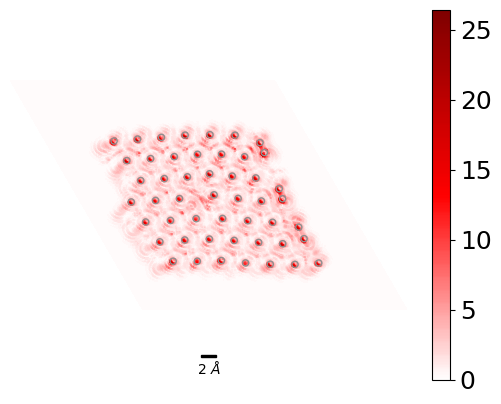

In [19]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap
cmap = plt.get_cmap('seismic')
new_cmap = truncate_colormap(cmap, 0.5, 1.0)
#cut plane normal y
cut_bounds = np.array([9.1,9.86])
cut_pos = np.array([0,0,9.1])
x_dists = np.round(np.abs(psi_coordinates[:,2] - cut_pos[2]),decimals=2)
minimum_indices = np.where(x_dists==x_dists.min())
#check if more than two sets of points are chosen somehow
print('are the points from single group?: ',np.all(psi_coordinates[minimum_indices][:,2] == psi_coordinates[minimum_indices][0,2]))
points2plot = psi_coordinates[minimum_indices]
#qfnorm2plot = potential_force_norm_flat[minimum_indices]
#qfnorm2plot = kinetic_force_norm_flat[minimum_indices]
qfnorm2plot = quantum_force_norm_flat[minimum_indices] #/ np.max(quantum_force_norm_flat)
#qfnorm2plot = np.ravel(V_interpolated,order='C')[minimum_indices]
#qfnorm2plot = np.ravel(nabla_V_norm,order='C')[minimum_indices]
#qfnorm2plot = np.ravel(n,order='C')[minimum_indices]
print('range max: ',np.max(qfnorm2plot))
plt.close('all')
fig1, ax1 = plt.subplots()
fig1.set_dpi(100)
norm= cm.colors.Normalize(vmin=0, vmax=np.max(qfnorm2plot))
plt.tricontourf(points2plot[:,0],points2plot[:,1],qfnorm2plot,100,cmap=new_cmap,norm=norm)

atom_plotter(ax1,disp_data, cut_bounds,4)
scalebar = AnchoredSizeBar(ax1.transData,
                           2, r'2 $\AA$', 'lower center', 
                           pad=0.1,
                           color='black',
                           frameon=False,
                           size_vertical=0.2,)

ax1.add_artist(scalebar)

sm = plt.cm.ScalarMappable(norm=norm, cmap = new_cmap)
cbar = fig1.colorbar(sm)
cbar.ax.tick_params(labelsize=18)
#plt.colorbar()
ax1.axis('equal')
#plt.colorbar()
plt.axis('off')

#ax1.set_xlim([3,8])
#ax1.set_ylim([4.5,6.5])
fig1.savefig('f_psi.png',dpi=200,transparent=True)


Average the force profiles

In [21]:
#Make a table, elements separated by whitespace,
#Always five columns
poscar_data = poscar_ops()
poscar_data.poscar_reader('CONTCAR')
print('species: ',poscar_data.species)
print('species numbers: ', poscar_data.species_nums)
C_positions = poscar_data.coords[0]
Si_positions = poscar_data.coords[1]
N_positions = poscar_data.coords[2]

POSCAR read
species:  ['C', 'Si', 'N']
species numbers:  [195.0, 195.0, 1.0]


In [22]:
adding_array = [-1.0,0.0,1.0]
psi_coords_pb = psi_coordinates
quantum_force_pb = quantum_force_norm_flat
#quantum_force_vec_pb = quantum_force_flat
for i in range(3):
    for j in range(3):
        for k in range(3):
            if i == 0 and j == 0 and k == 0:
                continue
            psi_coords_temp = psi_coordinates + adding_array[i] * box_vectors[0,:] + adding_array[j] * box_vectors[1,:] + adding_array[k] * box_vectors[2,:]
            np.append(psi_coords_pb,psi_coords_temp,axis=0)
            np.append(quantum_force_pb,quantum_force_norm_flat,axis=0)
            #np.append(quantum_force_vec_pb,quantum_force_flat,axis=0)

In [23]:
#form the KD tree for neighbor lookup
tree = scipy.spatial.KDTree(psi_coords_pb)

#now we are going to apply modified inverse distance weghing interpolation
#https://en.wikipedia.org/wiki/Inverse_distance_weighting
radius = 0.12
def weight_function(query_point,tree,radius):
    neigh = tree.query_ball_point(query_point,radius)
    if len(neigh) == 0:
        print('error no neighbours')
        print(query_point)
        raise Exception("No neighbor error. Skip the atom")
    w = np.zeros((len(neigh),),dtype='float')
    dists = np.linalg.norm(tree.data[neigh] - query_point,axis=1)
    if np.any(dists==0.0):
        w[np.where(dists==0.0)] = 1.0
        return w, neigh
    w = np.square((np.maximum(0.0,radius - dists) / (radius * dists)))
    return w, neigh

In [24]:
radius_sphere = np.linspace(0.0,2.0,100,endpoint=True)
lebedev = np.loadtxt('lebedev_131.txt')
lebedev_grid_points = np.zeros((len(lebedev),3))
lebedev_grid_points[:,0] = np.cos(np.radians(lebedev[:,0])) * np.sin(np.radians(lebedev[:,1]))
lebedev_grid_points[:,1] = np.sin(np.radians(lebedev[:,0])) * np.sin(np.radians(lebedev[:,1]))
lebedev_grid_points[:,2] = np.cos(np.radians(lebedev[:,1]))
lebedev_weights = lebedev[:,2]

def atom_profiler(rs,pos,tree,radius,lebedev_grid_points=lebedev_grid_points,lebedev_weights=lebedev_weights):
    force_profile = np.zeros(len(rs))
    skip_atom = False
    for r_count, r in enumerate(rs):
        enquiry_points = lebedev_grid_points * r + pos
        interpolated_f = np.zeros((len(enquiry_points[:,0])))
        #print('r: ',r)
        for i,pt in enumerate(enquiry_points):
            try:
                weights, neighs = weight_function(pt,tree,radius)
            except Exception as e:
                skip_atom = True
                break
            interpolated_f[i] = np.dot(quantum_force_pb[neighs], weights / sum(weights))
        if skip_atom == True:
            return force_profile, skip_atom
        force_profile[r_count] = np.dot(interpolated_f,lebedev_weights)
    return force_profile, skip_atom

C

In [25]:
#average the Carbons
C_force_profile = np.zeros((len(C_positions[:,0]),len(radius_sphere)))
skipped_atoms = 0
for atom_count, atom in enumerate(C_positions):
    pos = box_vectors[0,:] * atom[0] + box_vectors[1,:] * atom[1] + box_vectors[2,:] * atom[2]
    #print('pos: ',pos)
    skip_atom = False
    C_force_profile[atom_count,:], skip_atom = atom_profiler(radius_sphere,pos,tree,radius)
    if skip_atom == True:
        C_force_profile[atom_count,:] = 0.0
        skipped_atoms = skipped_atoms + 1

error no neighbours
[ 3.39377044  5.39130203 -0.09077475]
error no neighbours
[ 3.94788563  6.1405264  10.07043713]
error no neighbours
[ 7.02849022  6.15450578 10.08066881]
error no neighbours
[10.1207694   6.22828152 10.07585044]
error no neighbours
[13.23042837  5.93721079 10.07260165]
error no neighbours
[16.40194402  5.78879296 10.07031212]
error no neighbours
[19.51269706  5.76696013 10.07704144]
error no neighbours
[21.02824735  4.77231935 -0.08716876]
error no neighbours
[22.59298827  5.93163871 10.07738493]
error no neighbours
[ 2.28270411  8.58605604 10.07551918]
error no neighbours
[ 5.48057381  8.84024075 10.05837753]
error no neighbours
[ 8.59263506  8.98120176 10.07686992]
error no neighbours
[11.76322949  8.81897527 10.06556842]
error no neighbours
[14.90214993  8.60641037 10.06170719]
error no neighbours
[17.96690314  8.3798186  10.07937926]
error no neighbours
[19.65385869  7.43224311 -0.08673268]
error no neighbours
[20.73171772  8.99827503 10.07012349]
error no neigh

In [26]:
skipped_atoms

53

In [27]:
C_force_profile = np.sum(C_force_profile,axis=0) / (len(C_force_profile[:,0]) - skipped_atoms)

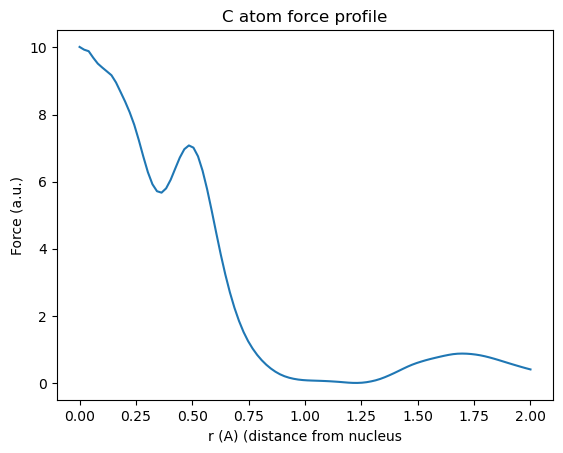

In [28]:
plt.close('all')
fig1, ax1 = plt.subplots()
fig1.set_dpi(100)
plt.plot(radius_sphere,(C_force_profile - C_force_profile.min())  )
plt.title('C atom force profile')
plt.xlabel('r (A) (distance from nucleus')
plt.ylabel('Force (a.u.)')
plt.savefig('C_force_profile.png',dpi=200,transparent=True)

In [29]:
np.savez_compressed('C_force.npz',f=C_force_profile,r=radius_sphere)

Silicon

In [30]:
#average the Silicons
Si_force_profile = np.zeros((len(Si_positions[:,0]),len(radius_sphere)))
skipped_atoms = 0
for atom_count, atom in enumerate(Si_positions):
    pos = box_vectors[0,:] * atom[0] + box_vectors[1,:] * atom[1] + box_vectors[2,:] * atom[2]
    #print('pos: ',pos)
    skip_atom = False
    Si_force_profile[atom_count,:], skip_atom = atom_profiler(radius_sphere,pos,tree,radius)
    if skip_atom == True:
        Si_force_profile[atom_count,:] = 0.0
        skipped_atoms = skipped_atoms + 1

error no neighbours
[ 2.4209287   5.40016319 -0.08393289]
error no neighbours
[ 5.41296386  5.51643674 -0.09819776]
error no neighbours
[ 8.64917316  5.62866788 -0.09922004]
error no neighbours
[11.55453186  5.51464555 -0.09050466]
error no neighbours
[14.87127205  5.34473019 -0.10333272]
error no neighbours
[17.92862206  5.2301056  -0.09633226]
error no neighbours
[21.15360405  5.12415163 -0.10769646]
error no neighbours
[ 0.74038906  7.75734912 -0.09605569]
error no neighbours
[ 3.86745689  7.90902114 -0.07757292]
error no neighbours
[ 7.02518545  8.03842905 -0.08903769]
error no neighbours
[10.11634732  8.03934102 -0.10383757]
error no neighbours
[13.28183678  7.79148516 -0.09771425]
error no neighbours
[16.4125106   7.61071781 -0.10022697]
error no neighbours
[19.56338101  7.59394237 -0.08778088]
error no neighbours
[-0.83737547  9.95303672 -0.10077613]
error no neighbours
[ 2.08212149 10.38952113 -0.10223463]
error no neighbours
[ 5.31684259 10.69962474 -0.07839836]
error no neigh

In [31]:
Si_force_profile = np.sum(Si_force_profile,axis=0) / (len(Si_force_profile[:,0]) - skipped_atoms)

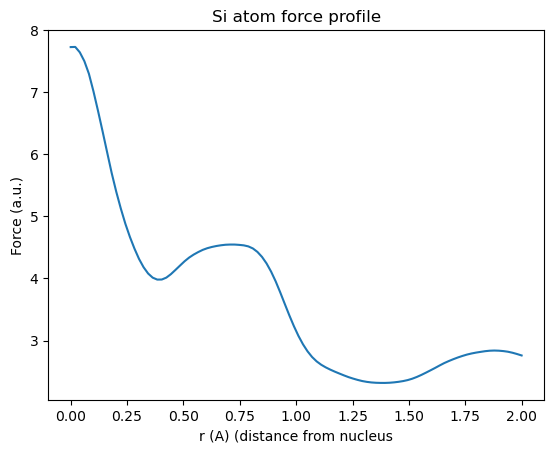

In [32]:
plt.close('all')
fig1, ax1 = plt.subplots()
fig1.set_dpi(100)
plt.plot(radius_sphere,Si_force_profile)#(H_force_profile - H_force_profile.min())[:35]  )
plt.title('Si atom force profile')
plt.xlabel('r (A) (distance from nucleus')
plt.ylabel('Force (a.u.)')
plt.savefig('Si_force_profile.png',dpi=200,transparent=True)

In [33]:
np.savez_compressed('Si_force.npz',f=Si_force_profile,r=radius_sphere)

Nitrogen

In [34]:
#average the Carbons
N_force_profile = np.zeros((1,len(radius_sphere)))
skipped_atoms = 0
for atom_count, atom in enumerate([N_positions[0,:]]):
    pos = box_vectors[0,:] * atom[0] + box_vectors[1,:] * atom[1] + box_vectors[2,:] * atom[2]
    #print('pos: ',pos)
    skip_atom = False
    N_force_profile[atom_count,:], skip_atom = atom_profiler(radius_sphere,pos,tree,radius)
    if skip_atom == True:
        N_force_profile[atom_count,:] = 0.0
        skipped_atoms = skipped_atoms + 1

In [35]:
skipped_atoms

0

In [36]:
N_force_profile = np.sum(N_force_profile,axis=0) / (len(N_force_profile[:,0]) - skipped_atoms)

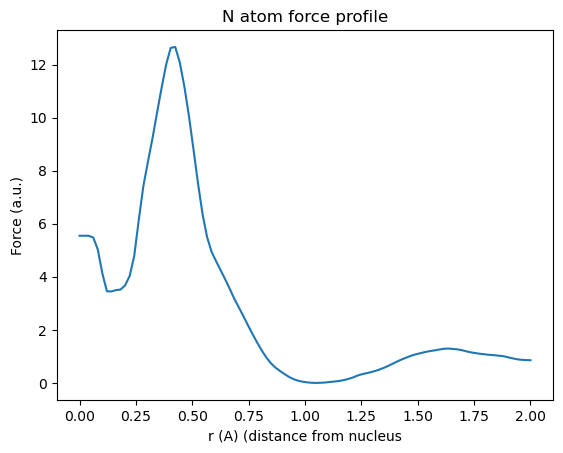

In [37]:
plt.close('all')
fig1, ax1 = plt.subplots()
fig1.set_dpi(100)
plt.plot(radius_sphere,(N_force_profile - N_force_profile.min())  )
plt.title('N atom force profile')
plt.xlabel('r (A) (distance from nucleus')
plt.ylabel('Force (a.u.)')
plt.savefig('N_force_profile.png',dpi=200,transparent=True)

In [38]:
np.savez_compressed('N_force.npz',f=N_force_profile,r=radius_sphere)

Now calculate F_ns

In [4]:
def sph_fourier_integrand(x,k,f,r):
    f_val = np.interp(x,r,f,right=0)
    if k == 0.0:
        #this is found by using the asymptotic approximation of BesselJ on Wolfram alpha
        return (2 * np.pi)**1.5 * 0.797884 * x**2 * f_val
    else:
        return (2 * np.pi)**1.5 * scipy.special.jv(0.5,x*k) * f_val * x**1.5 / (np.sqrt(k))
    
def F_n_integrand(k,x,kp,fp,n):
    f_head_val = np.interp(k,kp,fp,right=0)
    return f_head_val * scipy.special.spherical_jn(n,x*k)

Carbon

In [5]:
f_C = np.load('C_force.npz')['f']
r_C = np.load('C_force.npz')['r']
ks = np.linspace(0,100,500)
f_heads = []
for k in ks:
    res = scipy.integrate.quad(sph_fourier_integrand,0,1.2,args=(k,f_C,r_C))[0]
    f_heads.append(res)
                             

/tmp/ipykernel_28062/2381695816.py:6: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  res = scipy.integrate.quad(sph_fourier_integrand,0,1.2,args=(k,f_C,r_C))[0]


Text(0.5, 1.0, '$\\hat{f}$ for C')

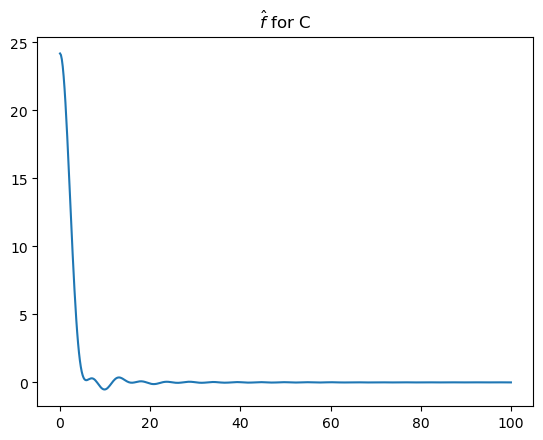

In [6]:
plt.close('all')
fig1, ax1 = plt.subplots()
fig1.set_dpi(100)
plt.plot(ks,f_heads)
plt.title(r'$\hat{f}$ for C')

In [7]:
#calculate the Fn
ns = [0,2,4,6,8,10,12,14,16,18,20]
xs = np.linspace(0,10000,10000)
Fn = np.zeros((len(xs),len(ns)+1))
Fn[:,0] = xs

for n_num, n in enumerate(ns):
    for x_num, x in enumerate(xs):
        res = scipy.integrate.quad(F_n_integrand,0,np.inf,args=(x,ks,f_heads,n,))[0]
        Fn[x_num,n_num+1] = res

/tmp/ipykernel_28062/4145566382.py:9: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  res = scipy.integrate.quad(F_n_integrand,0,np.inf,args=(x,ks,f_heads,n,))[0]
/tmp/ipykernel_28062/4145566382.py:9: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  res = scipy.integrate.quad(F_n_integrand,0,np.inf,args=(x,ks,f_heads,n,))[0]


Text(0.5, 1.0, '$F_{n}$ for C')

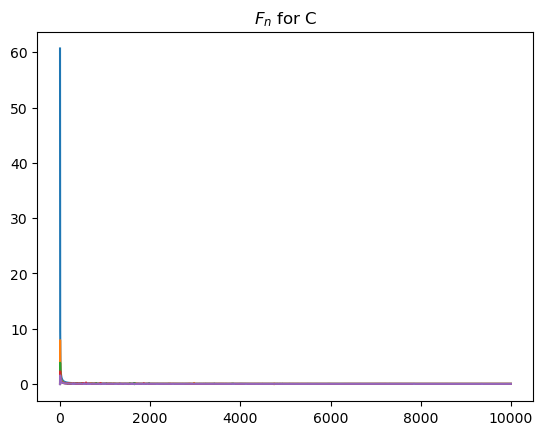

In [8]:
plt.close('all')
fig1, ax1 = plt.subplots()
fig1.set_dpi(100)
plt.plot(xs,Fn[:,1])
plt.plot(xs,Fn[:,2])
plt.plot(xs,Fn[:,3])
plt.plot(xs,Fn[:,4])
plt.plot(xs,Fn[:,5])
plt.title(r'$F_{n}$ for C')

In [9]:
np.savetxt('F/F_C.txt',Fn)

Silicon

In [10]:
f_Si = np.load('Si_force.npz')['f']
r_Si = np.load('Si_force.npz')['r']
ks = np.linspace(0,100,500)
f_heads = []
for k in ks:
    res = scipy.integrate.quad(sph_fourier_integrand,0,1.2,args=(k,f_Si,r_Si))[0]
    f_heads.append(res)
                            

/tmp/ipykernel_28062/1848855204.py:6: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  res = scipy.integrate.quad(sph_fourier_integrand,0,1.2,args=(k,f_Si,r_Si))[0]


Text(0.5, 1.0, '$\\hat{f}$ for Si')

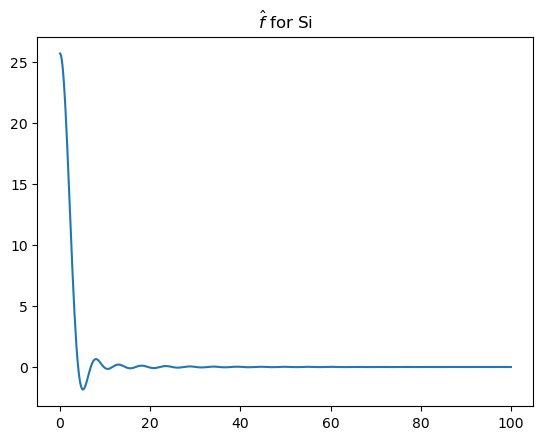

In [11]:
plt.close('all')
fig1, ax1 = plt.subplots()
fig1.set_dpi(100)
plt.plot(ks,f_heads)
plt.title(r'$\hat{f}$ for Si')

In [12]:
#calculate the Fn
ns = [0,2,4,6,8,10,12,14,16,18,20]
xs = np.linspace(0,10000,10000)
Fn = np.zeros((len(xs),len(ns)+1))
Fn[:,0] = xs

for n_num, n in enumerate(ns):
    for x_num, x in enumerate(xs):
        res = scipy.integrate.quad(F_n_integrand,0,np.inf,args=(x,ks,f_heads,n,))[0]
        Fn[x_num,n_num+1] = res

/tmp/ipykernel_28062/4145566382.py:9: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  res = scipy.integrate.quad(F_n_integrand,0,np.inf,args=(x,ks,f_heads,n,))[0]
/tmp/ipykernel_28062/4145566382.py:9: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  res = scipy.integrate.quad(F_n_integrand,0,np.inf,args=(x,ks,f_heads,n,))[0]


Text(0.5, 1.0, '$F_{n}$ for Si')

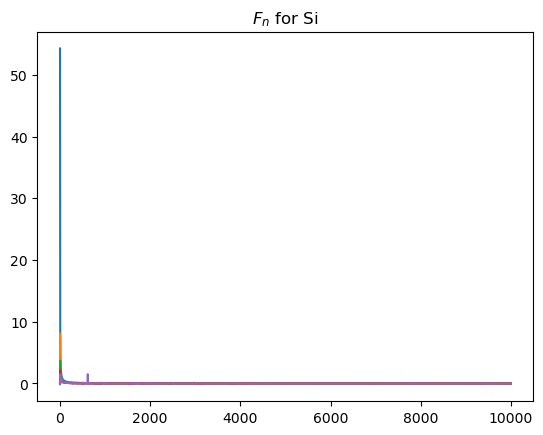

In [13]:
plt.close('all')
fig1, ax1 = plt.subplots()
fig1.set_dpi(100)
plt.plot(xs,Fn[:,1])
plt.plot(xs,Fn[:,2])
plt.plot(xs,Fn[:,3])
plt.plot(xs,Fn[:,4])
plt.plot(xs,Fn[:,5])
plt.title(r'$F_{n}$ for Si')

In [14]:
np.savetxt('F/F_Si.txt',Fn)

Nitrogen

In [15]:
f_N = np.load('N_force.npz')['f']
r_N = np.load('N_force.npz')['r']
ks = np.linspace(0,100,500)
f_heads = []
for k in ks:
    res = scipy.integrate.quad(sph_fourier_integrand,0,1.2,args=(k,f_N,r_N))[0]
    f_heads.append(res)
                      

/tmp/ipykernel_28062/1169464445.py:6: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  res = scipy.integrate.quad(sph_fourier_integrand,0,1.2,args=(k,f_N,r_N))[0]


Text(0.5, 1.0, '$\\hat{f}$ for N')

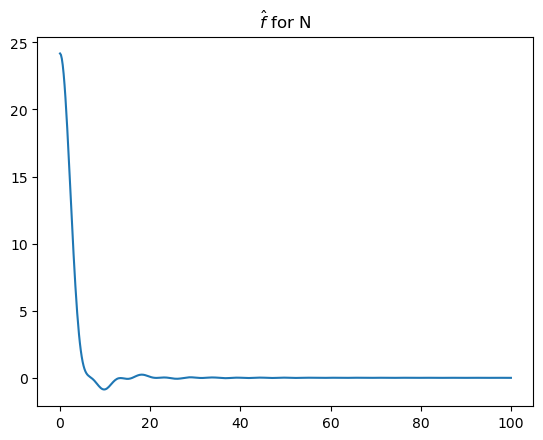

In [16]:
plt.close('all')
fig1, ax1 = plt.subplots()
fig1.set_dpi(100)
plt.plot(ks,f_heads)
plt.title(r'$\hat{f}$ for N')

In [17]:
#calculate the Fn
ns = [0,2,4,6,8,10,12,14,16,18,20]
xs = np.linspace(0,10000,10000)
Fn = np.zeros((len(xs),len(ns)+1))
Fn[:,0] = xs

for n_num, n in enumerate(ns):
    for x_num, x in enumerate(xs):
        res = scipy.integrate.quad(F_n_integrand,0,np.inf,args=(x,ks,f_heads,n,))[0]
        Fn[x_num,n_num+1] = res

/tmp/ipykernel_28062/4145566382.py:9: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  res = scipy.integrate.quad(F_n_integrand,0,np.inf,args=(x,ks,f_heads,n,))[0]
/tmp/ipykernel_28062/4145566382.py:9: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  res = scipy.integrate.quad(F_n_integrand,0,np.inf,args=(x,ks,f_heads,n,))[0]


Text(0.5, 1.0, '$F_{n}$ for N')

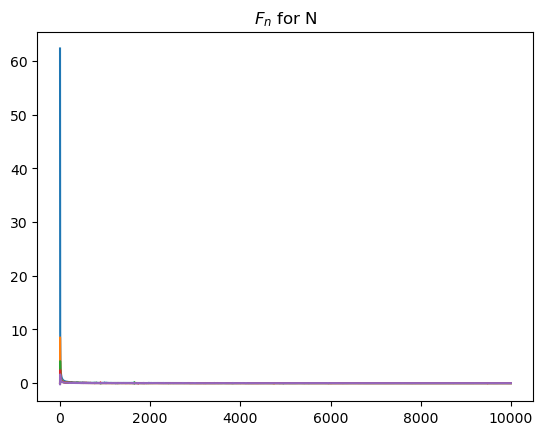

In [18]:
plt.close('all')
fig1, ax1 = plt.subplots()
fig1.set_dpi(100)
plt.plot(xs,Fn[:,1])
plt.plot(xs,Fn[:,2])
plt.plot(xs,Fn[:,3])
plt.plot(xs,Fn[:,4])
plt.plot(xs,Fn[:,5])
plt.title(r'$F_{n}$ for N')

In [19]:
np.savetxt('F/F_N.txt',Fn)